# Selection and read latency at a fixed row budget

Compare Paper greedy (GPU sorting) and Saturation on the same activation vector and row budget $R$. We measure time, retained importance and budget fill, extending 02's budget-based comparison to actual reads. The inputs are dense activation traces and a random weight-sized file.

The [paper](https://arxiv.org/html/2511.18692v1) supplies the Paper selector and Appendix H tuning procedure. Its main evaluation matches task accuracy; here equal budgets may retain different importance.

Fix 01's profile and 02's traces. Use `RUN_BENCHMARK = True` to tune and measure on the target SSD, or `False` to report saved results. After changing inputs or settings, rerun manually. Run from this notebook's directory.

In [1]:
from pathlib import Path
from time import perf_counter_ns
from tempfile import TemporaryDirectory
import json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROFILE = Path("../01/block_estimates.csv")
TRACE, UPSTREAM = Path("../02/activation_traces.npz"), Path("../../../upstream/vlm-flash")
RESULTS, ENVIRONMENT = Path("measured_results.csv"), Path("measured_environment.json")
RUN_BENCHMARK = False
MAX_TRACES_PER_SHAPE = 32
FRACTIONS = np.arange(3, 11) / 10  # paper sparsity 0.7 ... 0.0
WARMUP, REPEATS, THREADS = 3, 30, 6
PAPER, TILE = "Paper greedy (GPU sort)", "Saturation"

## Budget, importance and selectors

For a projection with $N$ rows and requested fraction $f$, both selectors receive $R=\max(1,\lfloor fN\rfloor)$. Archived importance is $v_i=\operatorname{mean}_{\rm batch,token}|x_i|$, normalized to mean one. A binary mask $M$ retains importance and fills its budget as

$$q(M)=\frac{\sum_i v_iM_i}{\sum_i v_i},\qquad
\operatorname{fill}(M)=\frac{\sum_i M_i}{R}.$$

Paper may underfill; Saturation selects exactly $R$ rows. At $R=N$, both bypass selection and read every row. An all-zero importance vector has undefined $q$; its timing remains usable. The default sweep covers sparsity 0–70% in ten-percentage-point steps.

The median profile from 01 defines $T(z)$, the cost in milliseconds of a $z$ KiB run. Upstream interpolates between profiled sizes, floors smaller reads at the smallest size, and extends the upper endpoint linearly. A mask's modeled cost is the sum over its maximal selected runs. Paper ranks windows by importance per cost and greedily accepts non-overlapping windows within $R$; its size ceiling is the largest profiled size.

For a row of $w$ KiB, Saturation uses $B=\lceil z_{\rm eff}/w\rceil$, where $z_{\rm eff}\in\arg\min_z T(z)/z$. At offsets $0$ and $\lfloor B/2\rfloor$, it takes the $\lfloor R/B\rfloor$ most important full tiles and the best disjoint interval of length $R\bmod B$. It keeps the mask with larger importance per modeled cost. If $R<B$, it takes the best length-$R$ interval.

In [2]:
if RUN_BENCHMARK:
    curve = pd.read_csv(PROFILE).groupby("size_kib").latency_ms.median().sort_index()
    boundary, ceiling = float((curve / curve.index).idxmin()), float(curve.index.max())

## Preparation and window tuning

Fresh runs require CUDA, upstream's native Paper selector and Saturation in `selectors.cpp`. Paper sorts on GPU and checks overlaps on CPU. Candidate geometry and cost tables are prepared before timing.

Upstream's Appendix H tuner uses random importance, sparsity 0.1, 30 repetitions, a 4–64 KiB grid in 4 KiB steps, and a 2 ms budget with a 20% margin. It chooses fine feasible windows, falling back to the fastest configuration if necessary. Parameters and feasibility counts are recorded. Tuning includes wrapper setup, so its times differ in scope from the prepared calls below.

In [3]:
if RUN_BENCHMARK:
    import torch
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path[:0] = [str((UPSTREAM / p).resolve()) for p in ("scripts", "src")]
    import vlmflash
    from vlmflash._native import native
    from vlmflash.policy import _window_sweep
    from profile_flash import write_blob, exclusive
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    reader = native()
    assert reader is not None, "Build the upstream native extension first."
    selectors = load("vlmflash_selection03", [str(Path("selectors.cpp").resolve())],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)
    table, cuda_available = vlmflash.LatencyTable(curve.to_dict()), torch.cuda.is_available()
    assert cuda_available, "Paper GPU-sort comparison requires CUDA."
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]]} for t in manifest["traces"]]
    groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
    traces = [g[i] for g in groups for i in np.linspace(0, len(g)-1,
              min(len(g), MAX_TRACES_PER_SHAPE or len(g)), dtype=int)]
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]

## Measurement

After `WARMUP` rounds, record `REPEATS` rounds with methods randomly interleaved. Let $t_0$ precede selection, $t_1$ follow it, and $t_2$ follow reader return:

$$t_{\rm selection}=t_1-t_0,\qquad t_{\rm wall}=t_2-t_0.$$

Native `io_ms` measures the read/thread interval. Wall time also includes read preparation. Selection includes Paper's GPU score transfers; GPU weight transfer and model computation are excluded.

The random file is written and fsynced on the target filesystem. Reads merge adjacent rows and use `THREADS` threads with requests up to 768 KiB; buffered fallback is rejected. The CSV preserves each repetition and selected intervals.

In [4]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    with exclusive("03_paper_saturation"), TemporaryDirectory(dir=RESULTS.parent) as work:
        profile_path, tuned_path = Path(work) / "profile.json", Path(work) / "tuned.json"
        profile_path.write_text(json.dumps(dict(format="vlmflash-latency-table-v1", table=curve.to_dict())))
        subprocess.run([sys.executable, str(UPSTREAM / "scripts/tune_chunk_params.py"),
            "--profile", str(profile_path), "--shapes", *sorted({t["shape"] for t in traces}),
            "--dtype-bytes", str(weight_bytes), "--impl", "native", "--output", str(tuned_path)],
            env={**os.environ, "OMP_NUM_THREADS": "1", "MKL_NUM_THREADS": "1"}, check=True)
        tuning = json.loads(tuned_path.read_text())
        blob = str(Path(work) / "rows.dat")
        write_blob(blob, max(t["n"] * t["d"] * weight_bytes for t in traces))
        for index, trace in enumerate(traces, 1):
            v = trace["values"].astype(np.float32)
            v = v / v.mean() if v.any() else v
            values, N = torch.from_numpy(v), len(v)
            total_importance = float(values.double().sum())
            row_bytes = weight_bytes * trace["d"]
            w, tuned = row_bytes / 1024, tuning[trace["shape"]]["best"]
            B = int(np.ceil(boundary / w))
            costs = torch.tensor([0.] + [table.read_ms(w*r) for r in range(1, N+1)], dtype=torch.float64)
            params = vlmflash.ChunkParams(start_kb=tuned["start_kb"], jump_cap_kb=tuned["jump_cap_kb"])
            windows, stride = _window_sweep(N, w, table, params)
            sizes = torch.tensor([r for r, _ in windows], dtype=torch.int64)
            delays = torch.tensor([t for _, t in windows], dtype=torch.float64)
            for fraction in FRACTIONS:
                R, dense = max(1, int(round(float(fraction), 6)*N)), torch.ones(N, dtype=torch.uint8)
                functions = {
                    PAPER: lambda: reader.select_chunks(values, R, sizes, delays, stride, True)[0],
                    TILE: lambda: selectors.tiles(values, R, costs, B)[0]}
                checked = {}
                for name, fn in functions.items():
                    mask = dense if R == N else fn()
                    selected = int(mask.sum())
                    assert selected <= R if name.startswith("Paper greedy") else selected == R
                    spans = np.flatnonzero(np.diff(np.r_[False, mask.numpy().astype(bool), False])).reshape(-1,2)
                    checked[name] = (mask.clone(), dict(R_selected=selected, fill_pct=100*selected/R,
                        retained_pct=100*float(values[mask.bool()].double().sum())/total_importance if total_importance else np.nan,
                        modeled_io_ms=float(costs[np.diff(spans).ravel()].sum()), runs=len(spans),
                        intervals=json.dumps(spans.tolist())))
                for repeat in range(-WARMUP, REPEATS):
                    for name in rng.permutation(list(functions)):
                        begin = perf_counter_ns()
                        mask = dense if R == N else functions[name]()
                        after_select = perf_counter_ns()
                        raw, io_us, _, direct = reader.read_rows(blob, mask, row_bytes, "cpu", THREADS, 768*1024, True)
                        end = perf_counter_ns()
                        assert direct, "O_DIRECT unavailable; refusing page-cache timings."
                        assert torch.equal(mask, checked[name][0])
                        assert raw.shape == (checked[name][1]["R_selected"], row_bytes)
                        if repeat >= 0:
                            records.append(dict(trace_id=trace["trace_id"], shape=trace["shape"],
                                fraction=float(fraction), R_nominal=R, tile_rows=B, method=name, repeat=repeat,
                                selection_ms=(after_select-begin)/1e6, io_ms=io_us/1000,
                                wall_ms=(end-begin)/1e6, **checked[name][1]))
            if index % 16 == 0 or index == len(traces):
                print(f"{index}/{len(traces)} traces measured", flush=True)
    pd.DataFrame(records).to_csv(RESULTS, index=False)
    environment = dict(platform=platform.platform(), torch=torch.__version__, cuda_available=cuda_available,
        paper_sort_devices=["cuda"], paper_tuning=tuning,
        torch_threads=torch.get_num_threads(), reader_threads=THREADS, direct_io=True, destination="cpu",
        tile_boundary_kib=boundary, paper_ceiling_kib=ceiling, traces=len(traces),
        warmup=WARMUP, repeats=REPEATS, fractions=FRACTIONS.tolist(), max_read_kib=768,
        measurement="prepared CPU importance through selected bytes on CPU; no model compute",
        upstream_commit=subprocess.check_output(["git","-C",str(UPSTREAM),"rev-parse","HEAD"],text=True).strip(),
        mount=subprocess.check_output(["findmnt","-T",str(RESULTS.resolve()),"-n","-o","SOURCE,FSTYPE,TARGET"],text=True).strip())
    ENVIRONMENT.write_text(json.dumps(environment, indent=2))

## Recorded run

The environment and tuning results describe the saved CSV. Missing or empty results stop execution; input changes are managed manually.

In [5]:
frame = pd.read_csv(RESULTS)
assert not frame.empty, "Run the measurement before evaluating the report."
environment = json.loads(ENVIRONMENT.read_text())
display(pd.Series(environment)[["platform", "torch", "reader_threads", "warmup", "repeats", "traces",
                                "direct_io", "tile_boundary_kib", "paper_ceiling_kib", "mount"]])
if "paper_tuning" in environment:
    display(pd.DataFrame({shape: {**t["best"], "feasible": t["num_feasible"]}
                          for shape, t in environment["paper_tuning"].items()}).T)
else:
    display(Markdown("**Saved run:** window tuning was not recorded. The analysis below uses the "
                     "existing measurements; rerun to apply and record the upstream tuning protocol."))
frame = frame[frame.method.isin([PAPER, TILE])].copy()
assert set(frame.method) == {PAPER, TILE}, "Measure both selectors before comparing them."
assert np.isfinite(frame.io_ms).all() and (frame.io_ms > 0).all(), "I/O times must be positive."

platform             Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
torch                                                     2.11.0+cu130
reader_threads                                                       6
warmup                                                               3
repeats                                                             30
traces                                                             128
direct_io                                                         True
tile_boundary_kib                                                256.0
paper_ceiling_kib                                                768.0
mount                                /dev/nvme1n1p3[/home] btrfs /home
dtype: object

,start_kb,jump_cap_kb,overhead_ms,est_read_ms,utility,rows_selected,feasible
4864x896,8.0,12.0,1.488,1.353,3246.608,4376.0,247.0
896x128,4.0,4.0,0.133,0.037,21392.786,800.0,256.0
896x4864,4.0,4.0,1.217,1.359,605.672,807.0,36.0
896x896,4.0,4.0,1.207,0.262,3112.827,806.0,256.0


## Observed time and retained importance

First take repetition medians within each trace/method/budget case. The table summarizes cases by shape and method, including the all-rows control. Undefined importance is omitted only from importance summaries.

Each plotted point takes medians across traces at one requested fraction $f$, in increasing $f$ order. Three figures show I/O, selection and wall time, using identical zero-based x-axis ranges and ticks within each shape. The curves show observed trade-offs; no equal-importance latency is inferred.

In [6]:
values = ["selection_ms", "io_ms", "wall_ms", "retained_pct", "fill_pct"]
keys = ["shape", "trace_id", "fraction", "R_nominal"]
cases = frame.groupby(keys + ["method"])[values + ["R_selected"]].median().reset_index()
assert cases.groupby(keys).method.nunique().eq(2).all(), "Each budget needs both methods."
display(cases.groupby(["shape", "method"])[values].median().round(4))

selection_ms   io_ms  wall_ms  retained_pct  \
shape    method                                                                 
4864x896 Paper greedy (GPU sort)        2.0512  1.2466   3.3405       71.7672   
         Saturation                     0.0420  1.4008   1.5022       69.9443   
896x128  Paper greedy (GPU sort)        0.1077  0.1545   0.2811       68.5282   
         Saturation                     0.0065  0.1580   0.1844       66.9594   
896x4864 Paper greedy (GPU sort)        1.6258  1.2358   2.9032       70.0392   
         Saturation                     0.0224  1.4196   1.4845       68.7398   
896x896  Paper greedy (GPU sort)        1.1440  0.3980   1.5683       75.8773   
         Saturation                     0.0130  0.4363   0.4746       73.8598   

                                  fill_pct  
shape    method                             
4864x896 Paper greedy (GPU sort)   99.9629  
         Saturation               100.0000  
896x128  Paper greedy (GPU sort)   98.7898  
         Saturation               100.0000  
896x4864 Paper greedy (GPU sort)  100.0000  
         Saturation               100.0000  
896x896  Paper greedy (GPU sort)  100.0000  
         Saturation               100.0000

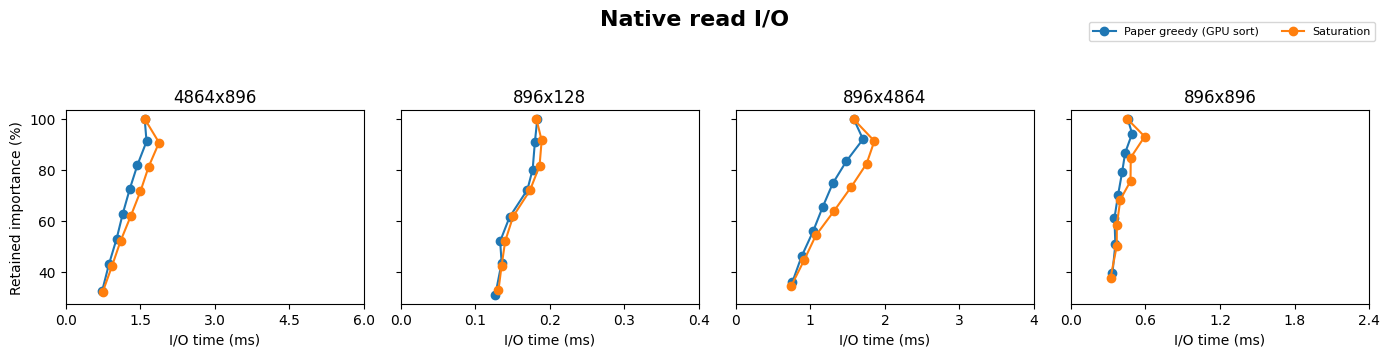

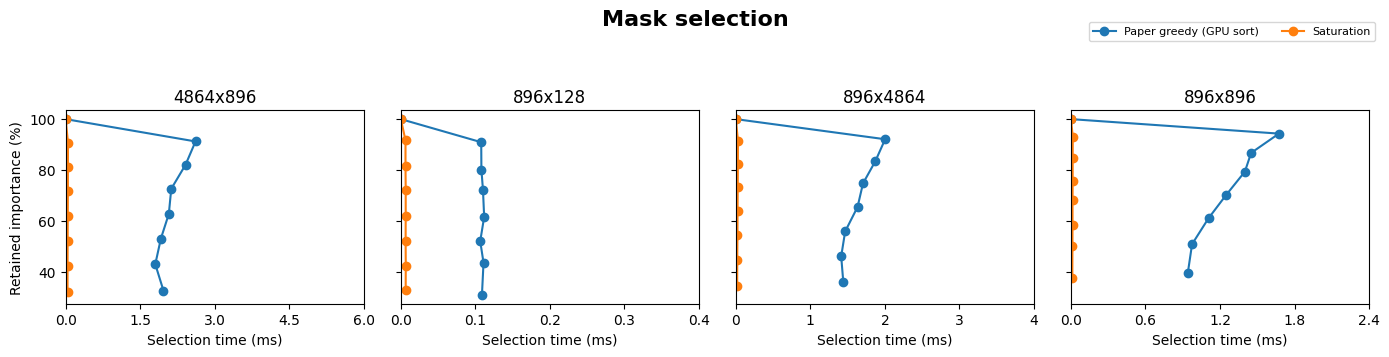

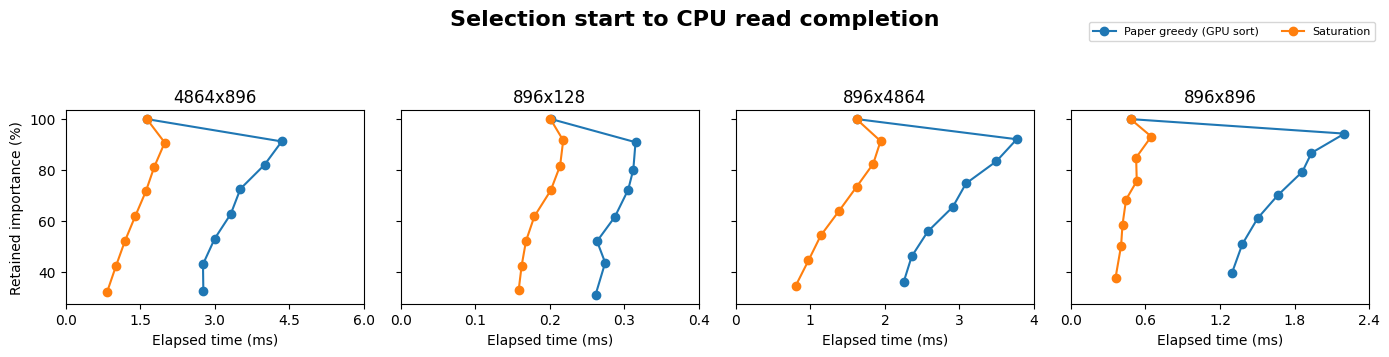

In [7]:
from matplotlib.ticker import MaxNLocator
metrics = (("io_ms", "Native read I/O", "I/O time (ms)"),
           ("selection_ms", "Mask selection", "Selection time (ms)"),
           ("wall_ms", "Selection start to CPU read completion", "Elapsed time (ms)"))
limits = {}
for shape, group in cases.groupby("shape"):
    peak = group.groupby(["fraction", "method"])[["io_ms", "selection_ms", "wall_ms"]].median().max().max()
    limits[shape] = MaxNLocator(nbins=4).tick_values(0, peak * 1.05)
for metric, title, xlabel in metrics:
    fig, axes = plt.subplots(1, len(limits), figsize=(14, 3.6), squeeze=False, sharey=True)
    fig.suptitle(title, fontsize=16, fontweight="bold")
    for column, (ax, (shape, group)) in enumerate(zip(axes.flat, cases.groupby("shape"))):
        for name, data in group.groupby("method"):
            points = data.groupby("fraction")[[metric, "retained_pct"]].median()
            ax.plot(points[metric], points.retained_pct, "o-", label=name)
        ticks = limits[shape]
        ax.set(title=shape, xlabel=xlabel, xlim=(0, ticks[-1]), xticks=ticks,
               ylabel="Retained importance (%)" if column == 0 else "")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(.99, .96),
               ncol=2, fontsize=8)
    fig.tight_layout(rect=(0, 0, 1, .90))
    plt.show()

## Reading the comparison

Subtract Paper from Saturation within each trace and requested budget, then take medians by shape. Negative time differences favor Saturation; positive importance differences mean it retains more importance. Percentage differences are in percentage points. Component medians are not added.

These results describe the time–importance trade-off at the same requested budget, rather than equal accuracy or full-model inference speedup.

In [8]:
paper = cases[cases.method == PAPER]
filled = int(paper.R_selected.eq(paper.R_nominal).sum())
display(Markdown(f"Across **{len(paper):,}** paired trace/budget cases, Paper fills $R$ exactly in "
    f"**{filled:,}**; its median fill is **{paper.fill_pct.median():.2f}%**. "
    "The differences below use the same requested budgets, which may retain different importance."))
paired = cases.set_index(keys + ["method"])[values]
differences = paired.xs(TILE, level="method") - paired.xs(PAPER, level="method")
display(differences.groupby("shape").median().rename(columns={
    "selection_ms": "Δ selection (ms)", "io_ms": "Δ I/O (ms)", "wall_ms": "Δ wall (ms)",
    "retained_pct": "Δ importance (pp)", "fill_pct": "Δ fill (pp)"}).round(4))

Across **1,024** paired trace/budget cases, Paper fills $R$ exactly in **608**; its median fill is **100.00%**. The differences below use the same requested budgets, which may retain different importance.

,Δ selection (ms),Δ I/O (ms),Δ wall (ms),Δ importance (pp),Δ fill (pp)
shape,,,,,
4864x896,-2.0077,0.1000,-1.9134,-0.7254,0.0371
896x128,-0.1010,0.0048,-0.0995,0.1079,1.2102
896x4864,-1.6032,0.0792,-1.4739,-1.1530,0.0000
896x896,-1.1318,0.0127,-1.0933,-1.4988,0.0000
